We want to find out if our inflationary model satisfies, $N_e$, $n_s$, $r$ are within observational bounds. $N_e$ is the number of e-folds inflation lasted for, we need it to last around 60 e-folds in order to solve the horizon and curvature problem. $n_s$ is the scalar spectral index, this the rate of change of CCCP as you look at different wavelenghts. $r$ is the tensor-to-scalar ratio, which is observationaly constrained by looking at the effective degrees of freedom of neutrinos caculated from the CMB.

It can be caculated that:

$n_s = 1 -2ϵ - η ≈ 1 -6ϵ_v + 2\eta_v$


$r = 16ϵ ≈ 16 ϵ_v$




Subsiquently we can also caculate (setting $M_p =1$ as done in the paper provided) so working in Plank Units :


$ϵ_v = \frac{1}{2}\left(\frac{V'}{V}\right)^2$


$\eta_v = \frac{V''}{V}$

Finding $N_e$ is slighlty more tricky, we need to find $\phi_e$ and $\phi_i$ which is our potential at the end and start of inflation.



As discussed in paper we are working in effective field theory, so we work in interval $[-30,30]$.

We apply another restriction saying that the global minima must fall inside $[-5,5]$. If not we give a fixed negative value for fitness (I will choose this to be the lowest value we can achieve, so the must unfit)


Step 1:
* Find $\phi_m$
* Find find closets maxima in either direction, if none found extend up to boundary
* Now we have a new bound on our system
* We split into left and right based around the minima and perform the same following steps on both

Step 2:
* Starting at $\phi_m$ we gradualy increase $\phi$ until $ϵ_v$ and $\eta_v$ drop below 0.5 (I would normaly have thought we do one, as I did on my comsology course), when this happens this gets us $\phi_e$
* We then caculate point when $ϵ_v$ or $\eta_v$ go back above 0.5, giving us $\phi_i$, there is another constraint given in the paper due to quantum fluctations. For the sake of time I will not include this
* If none is found them $\phi_i$ is the boundary

Step 3:
* We now compute our values:
Before we do though we've gotta think about cosmology a bit more. The restrictions that we have on r and ns, were caculated from pertubations in the CMB. When pertubations re-enter the horizon they drop down exponentialy so we are mainly interested in pertubations that re-entered around the time of CMB. These pertubations left inflation when the field was $\phi*$ as caculated in a previous paper to the one referenced in this PS. We will approx $N_* ≈ 60$.



First Fitness Test
1. $N_e$ from a integral,

Apply fitness function (this is our $N_e \geq N*$:



$f_N(s) = -\frac{1}{10}\,(60 - N_{\mathrm{total}})\,\theta(60 - N_{\mathrm{total}})$


Same as one discussed in the paper, this is rather simple so I will use the same.



We caculate $ϵ_v$ and $\eta_v$ at $\phi*$ --> $ϵ_v*$, $\eta_v*$


Again the fitness methods use in the paper, do seem like the best method, $f_{term}=-0.3$, which is approx log(2) we get 0 fitness if within the bound!

2. $$
f_{n_s}(s)
=
\hat{f}_{n_s}(s)\,
\theta\!\left(f_{\mathrm{term}}-\hat{f}_{n_s}(s)\right),
$$

where

$$
\hat{f}_{n_s}(s)
=
-\log_{10}\!\left(
1+
\frac{\left|n_{s,*}-n_s\right|}{\Delta n_s}
\right).
$$

3. $$
f_r(s)
=
-\log_{10}\!\left(
\frac{r_*}{r_{\max}}
\right)
\theta\!\left(r_* - r_{\max}\right)
$$



Our search space is built up of the coefficeints up to c6, we don't include c0 as we want the minima of ur potential to be 0 such that this gives a very small value for the cosmological constant.


Our selection process will instead be tourmanent + elitism.

In [ ]:
import random as rnd
import heapq as hpq
import numpy as np
from scipy.optimize import root_scalar as root
from scipy.integrate import quad as integrate


#Table between our binary numbers and their logarthmic values
#For the sake of time my parameters will be fixed in here rather than dependent on the inputs to the function
def table():
  #We need to create the 384 numbers for our coeffecients
  c = np.zeros((64,6))
  #Lets now fill in c with logarthmicly spaced points
  magC = np.array([8,9,10,11,11,11])
  for i, magC in enumerate(magC):
    #We have to arbitarly decide how small the values get
    mag = np.logspace(-magC-5,-magC,32)
    c[:,i] = np.concatenate((-mag[::-1],mag))

  return c

def stateToCoef(state,c):
  coef = np.zeros(6)
  for i in range(6):
    #Split up into genes, which what people call each logical part of a chromosone so for us
    #each coeffecient biniary numbner
    gene = state[6*i:6*(i+1)]
    weight = np.array([32,16,8,4,2,1])
    #Converts our gene from a numpy into an index
    index = gene.dot(weight)
    coef[i] = c[index,i]
  return coef

# Generate initial population
def intPop(popSize):
  # Population List
  #I am using uint8 as this is more effecient cos just dealing with binary numbers
  return np.random.randint(0,2,(popSize,36), dtype = np.uint8)

#V
def V(phi,coef):
  return (coef[0]*phi + coef[1]*phi**2 + coef[2]*phi**3 + coef[3]*phi**4 + coef[4]*phi**5 + coef[5]*phi**6)

#V'
def Vprime(phi,coef):
  return (coef[0] + 2*coef[1]*phi + 3*coef[2]*phi**2 + 4*coef[3]*phi**3 + 5*coef[4]*phi**4 + 6*coef[5]*phi**5)

#V''
def VdoublePrime(phi,coef):
  return (2*coef[1] + 6*coef[2]*phi + 12*coef[3]*phi**2 + 20*coef[4]*phi**3 + 24*coef[5]*phi**4)


#Epsilon Func
def epsilon(v,vprime):
  if v < 0:
    return 100
  else:
    return 0.5*(vprime/v)**2


#Eta Func
def eta(v,vdprime):
  if v < 0:
    return 100
  else:
    return vdprime/v

def findPhi1(phi,v,vdprime,vprime,increment):
  if phi*np.sign(increment) >= 30:
    #Sign we didn't get a phi, just picked number we could not get otherwise
    return 50
  phi += increment
  if epsilon(v(phi), vprime(phi)) <= 0.5 and abs(eta(v(phi), vdprime(phi))) <= 0.5:
    return phi
  else:
    return findPhi1(phi,v,vdprime,vprime,increment)

def findPhi2(phi,v,vdprime,vprime,increment):
  if phi*np.sign(increment) > 30:
    return phi
  phi += increment
  if epsilon(v(phi), vprime(phi)) > 0.5 or abs(eta(v(phi), vdprime(phi))) > 0.5:
    return phi
  else:
    return findPhi2(phi,v,vdprime,vprime,increment)


def findfitnessBothSide(phi_m,v,vdprime,vprime,increment):
  phi_e = findPhi1(phi_m,v,vdprime,vprime,increment)
  if phi_e == 50:
    return -1000
  else:
    phi_i = findPhi2(phi_e,v,vdprime,vprime,increment)

  #Define Function handle
  integrand = lambda x: v(x)/vprime(x)

  #Find phi*
  F = lambda x: integrate(integrand,phi_e,x)[0]-60
  try:
    phi_star = root(F, bracket= [phi_e,phi_i])
    phi_star = phi_star.root
  except ValueError:
    #Means that phi* N lasts less than N*
    #We will aproximate by saying phi_i is phi_star
    #We could also give large negative to remove from gene pool
    #Bit will refain from doing in so, otherwise no point of Ne > 60
    #Fitness check
    phi_star = phi_i
  #Find Ne
  #Integrate
  Ne = F(phi_i) + 60
  #Find epsilon
  epsilon_v = epsilon(v(phi_star),vprime(phi_star))
  r = 16*epsilon_v
  #Find eta
  eta_v = eta(v(phi_star),vdprime(phi_star))
  ns = 1 - 6*epsilon_v + 2*eta_v

  #Find Fitness
  f = 0
  f += 0.1*(Ne-60)*np.heaviside(60-Ne,0)
  f += np.log10(0.07/r)*np.heaviside(r-0.07,0)
  l = -np.log10(1+abs(ns-0.965)*100)
  f += l*np.heaviside(-0.3 -l,0)
  return f

def find_minimum(coef, lo=-5, hi=5, ngrid=1000):
    vprime = lambda phi: Vprime(phi, coef)
    vdprime = lambda phi: VdoublePrime(phi, coef)
    v = lambda phi: V(phi, coef)

    xs = np.linspace(lo, hi, ngrid)
    vals = np.array([vprime(x) for x in xs])

    roots = []

    for i in range(len(xs)-1):
        if not np.isfinite(vals[i]) or not np.isfinite(vals[i+1]):
            continue

        if vals[i] == 0:
            roots.append(xs[i])

        elif vals[i] * vals[i+1] < 0:
            try:
                res = root(vprime, bracket=[xs[i], xs[i+1]])
                if res.converged:
                    roots.append(res.root)
            except ValueError:
                pass

    minima = [r for r in roots if vdprime(r) > 0]

    if len(minima) == 0:
        return None

    # choose lowest minimum
    return min(minima, key=v)

#Fitness Function
def fitFnc(coef):
  #Caculate phi minimum
  #Need to handle potnetial error from there being no minima
  #This just a function handle, like in MATLAB
  # v = lambda phi: V(phi,coef)
  # vprime = lambda phi: Vprime(phi,coef)
  # vdprime = lambda phi: VdoublePrime(phi,coef)
  # try:
  #   #Find Minima
  #   phi_m = root(vprime, bracket= [-5,5])
  #   phi_m = phi_m.root
  # except ValueError:
  #   #No Root found, give lowest fitness
  #   return -1000
  #Find phi_e and phi_i
  #For both left and right

  phi_m = find_minimum(coef)

  if phi_m is None:
    return -1000

  v0 = V(phi_m,coef)
  v = lambda phi: V(phi, coef) - v0
  vprime = lambda phi: Vprime(phi, coef)
  vdprime = lambda phi: VdoublePrime(phi, coef)

  #Right
  increment = 0.2
  fitR = findfitnessBothSide(phi_m,v,vdprime,vprime,increment)
  increment = -0.2
  fitL = findfitnessBothSide(phi_m,v,vdprime,vprime,increment)
  if fitR > fitL:
    return fitR
  else:
    return fitL

def tourmanet(k,pop):
  fighters = np.random.choice(len(pop), size=k, replace=False)
  return fighters[np.argmax(pop[fighters])]

def singlePointCross(p1,p2):
  crossOverPoint = rnd.randint(1,len(p1)-1)
  child1 = np.concatenate((p1[:crossOverPoint],p2[crossOverPoint:]))
  child2 = np.concatenate((p2[:crossOverPoint],p1[crossOverPoint:]))
  return (child1, child2)

# Mutation Function
def mutationFunc(state,p):
  for i in range(len(state)):
    if rnd.random() < p:
      state[i] ^= 1
  return state


def geneticAlgo(Popsize,noGen,p):

  #Make Population
  pop = intPop(Popsize)
  c = table()


  for i in range(noGen):

    #Convert into matrix of coeffecients
    popC = np.array([stateToCoef(pop[i],c) for i in range(len(pop))])
    #Convert matrix of coef into fitness scores
    fitness = np.array([fitFnc(coef) for coef in popC])
    #Elitism
    elite_frac = 0.05
    nElite = max(1, int(Popsize * elite_frac))
    elite = np.argsort(fitness)[-nElite:]
    newPop = np.zeros((Popsize,36),dtype=np.uint8)
    newPop[:nElite] = pop[elite]
    i = nElite

    while i < Popsize:
      #Tourmanent
      #Tourmanet Size: 5
      child1, child2 = singlePointCross(pop[tourmanet(5,fitness)],pop[tourmanet(5,fitness)])

      newPop[i] = mutationFunc(child1,p)
      i += 1
      if i < Popsize:
        newPop[i] = mutationFunc(child2,p)
        i += 1

    pop = newPop

  return newPop

final_state = geneticAlgo(100,50,0.01)
fitness = np.array([fitFnc(stateToCoef(final_state[i],table())) for i in range(len(final_state))])

goodStates_idx = np.where(fitness==0)[0]
goodStates = final_state[goodStates_idx]
goodStates = [stateToCoef(goodStates[i],table()) for i in range(len(goodStates))]
print(goodStates)
np.save("goodStates.npy", goodStates)


/tmp/ipykernel_1417/700772069.py:99: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  F = lambda x: integrate(integrand,phi_e,x)[0]-60
/tmp/ipykernel_1417/700772069.py:99: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  F = lambda x: integrate(integrand,phi_e,x)[0]-60
/tmp/ipykernel_1417/700772069.py:99: IntegrationWarning: The algorithm does not converge.  Roundoff error is detected
  in the extrapolation table.  It is assumed that the requested tolerance
  cannot be achieved, and that the returned result (if full_output = 1) is 
  the best which can 

[array([-5.51995432e-11, -3.80754602e-12, -2.62636353e-13,  6.89778538e-12,
       -3.80754602e-14, -8.61953566e-15]), array([-1.68192432e-10, -3.80754602e-12, -2.62636353e-13,  6.89778538e-12,
       -3.80754602e-14, -8.61953566e-15]), array([-5.51995432e-11, -7.42963951e-11, -3.04698957e-15,  6.89778538e-12,
       -3.80754602e-14, -8.61953566e-15]), array([-5.51995432e-11, -7.42963951e-11, -3.04698957e-15,  6.89778538e-12,
       -3.80754602e-14, -8.61953566e-15]), array([-5.51995432e-11, -1.95129342e-13,  6.40400427e-15,  6.89778538e-12,
       -3.80754602e-14, -8.61953566e-15]), array([-5.51995432e-11, -1.44974067e-14, -3.04698957e-15,  6.89778538e-12,
       -3.80754602e-14, -8.61953566e-15]), array([-1.68192432e-10, -3.80754602e-12, -5.94557071e-14,  6.89778538e-12,
       -3.80754602e-14, -8.61953566e-15]), array([-1.68192432e-10, -3.80754602e-12, -2.62636353e-13,  6.89778538e-12,
       -3.80754602e-14, -8.61953566e-15]), array([-3.80754602e-11, -7.42963951e-11, -5.94557071e-1

In [ ]:
#Analysis my good states :)
#Should probably clarify good states, means it has a fitness of 0, so it is an allowed in flatinoary model!!!
#How many are duplicates
unique = np.unique(goodStates,axis=0)
uniqueNo = len(unique)
duplicate= len(goodStates)- uniqueNo
print(f"Number of duplicate states: {duplicate}")
print(f"Number of unique states: {uniqueNo}")
print(unique)



Number of duplicate states: 50
Number of unique states: 26
[[-3.53498111e-10 -1.00000000e-14 -2.62636353e-13  6.89778538e-12
  -3.80754602e-14 -8.61953566e-15]
 [-2.43835410e-10 -3.80754602e-12 -2.62636353e-13  6.89778538e-12
  -3.80754602e-14 -8.61953566e-15]
 [-1.68192432e-10 -7.42963951e-11 -1.34596032e-14  6.89778538e-12
  -3.80754602e-14 -8.61953566e-15]
 [-1.68192432e-10 -7.42963951e-11 -3.04698957e-15  6.89778538e-12
  -3.80754602e-14 -8.61953566e-15]
 [-1.68192432e-10 -8.00250228e-12 -2.62636353e-13  6.89778538e-12
  -3.80754602e-14 -8.61953566e-15]
 [-1.68192432e-10 -5.51995432e-12 -2.62636353e-13  6.89778538e-12
  -3.80754602e-14 -8.61953566e-15]
 [-1.68192432e-10 -3.80754602e-12 -2.62636353e-13  6.89778538e-12
  -3.80754602e-14 -8.61953566e-15]
 [-1.68192432e-10 -3.80754602e-12 -5.94557071e-14  6.89778538e-12
  -3.80754602e-14 -8.61953566e-15]
 [-1.68192432e-10 -1.00000000e-14 -2.62636353e-13  6.89778538e-12
  -3.80754602e-14 -8.61953566e-15]
 [-5.51995432e-11 -1.07710506e-1

They all have very similar coeffecients, there was a lot of duplicates created as well.

We will now re-approach the problem from a reinforcement learning perspective. The action space is rather clear in our set up, and is moving to "nearest neighbour" in our 6 dimmensional space (each dimmension is each coeffecient).


The reward function can just be the change in the fitness function, we want our fitness function to increase so the reward is then just R = f(s') - f(s)


We will use deep RL, using a neural network to be our policy.


As discussed in lectures our L = sum Gt NN(t), where NN is our policy which is a neural network. We caculate this sum after every period and therefore do backprop after every period.

In [ ]:
#Import PyTorch
import torch
import torch.nn as nn
import random


# We define a class for our neural network
class NN(nn.Module):
  def __init__(self, input_size, output_size):
    super(NN, self).__init__()

    self.net = nn.Sequential(
        nn.Linear(input_size, 128),
        nn.ReLU(),
        nn.Linear(128, output_size),
        nn.Softmax()
    )

  def forward(self,x):
      return self.net(x)

#Some cheeky recursion
def G(val,t,gamma,reward,Period):
  if t < Period:
    val += (gamma**t)*reward[t]
    t += 1
    return G(val,t,gamma,reward,Period)
  return val


#Our state space
# We have 12 states
# Apply a softmax as the last part to our function
# Then the output is a probability of performing eacha action

#Our action comes straight from our neural network
#and is the probability of performing a given action
def step(current_state,actionIndex):
  #actionIndex is the action chosen by the nextwork
  #actionSpace is the associated action, it is a +/- k, where k is [1,5]

  #I ned to make a copy of my current_state cos when you change you edit the indices of a list on an object it affects it globaly in python
  current_state = current_state.copy()

  actionSpace = [1, -1, 2, -2, 3, -3, 4, -4, 5, -5, 6, -6]
  action = actionSpace[actionIndex]
  k = abs(action)
  start = 6*(k-1)
  end = 6*k
  binary = current_state[start:end]
  #Make our state into a integer
  value = int("".join(binary.astype(str)), 2)
  value += np.sign(action)
  if 0 <= value <= 63:
    #No overflow, so we are saying of on edge of our state space and try to move of it
    #we don't move rather than looping round for example

    #Convert back into binary vector
     current_state[start:end] = np.array(list(f"{value:06b}"), dtype=int)

  #Returns new state
  return current_state


#Choose initial state
def startPos():
  return np.random.randint(0,2,36, dtype = np.uint8)


def RLAlgo(gamma,PeriodNo,Period):

  #Create an object of our neural network class
  c = table()
  model = NN(36,12)
  optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


  for j in range(PeriodNo):

    current_state = startPos()

    #Remmebering for each period
    rewardMem = []
    logLossMem = []

    for i in range(Period):
      state_tensor = torch.tensor(current_state, dtype=torch.float32)
      actionProb = model(state_tensor)

      #We need to save our probability distribution in order to backprop on its log later
      dist = torch.distributions.Categorical(actionProb)
      #Sample an action from this distribution
      action_index = dist.sample()
      #Caculate the log of this distribution
      log_prob = dist.log_prob(action_index)
      logLossMem.append(log_prob)

      #Apply .item() cos currently action_index is a 1 dim. tensor
      next_state = step(current_state,action_index.item())
      #Caculate reward
      reward = fitFnc(stateToCoef(next_state,c)) - fitFnc(stateToCoef(current_state,c))
      rewardMem.append(reward)
      current_state = next_state

    #Apply backprop
    L = torch.tensor(0.0)
    for t in range(Period):
      Gt = G(0,t,gamma,rewardMem,Period)
      L += -Gt*logLossMem[t]

    optimizer.zero_grad()
    L.backward()
    optimizer.step()

  #Search for optimum value
  current_state = startPos()
  for i in range(100):
    state_tensor = torch.tensor(current_state, dtype=torch.float32)
    actionProb = model(state_tensor)
    dist = torch.distributions.Categorical(actionProb)
    action_index = dist.sample()
    current_state = step(current_state,action_index.item())

  print(fitFnc(stateToCoef(current_state,c)))

RLAlgo(0.8,100,10)




/tmp/ipykernel_3520/2686705164.py:99: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  F = lambda x: integrate(integrand,phi_e,x)[0]-60
/tmp/ipykernel_3520/2686705164.py:99: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  F = lambda x: integrate(integrand,phi_e,x)[0]-60
/tmp/ipykernel_3520/2686705164.py:99: IntegrationWarning: The algorithm does not converge.  Roundoff error is detected
  in the extrapolation table.  It is assumed that the requested tolerance
  cannot be achieved, and that the returned result (if full_output = 1) is 
  the best which c

-1.1451868724402958


The RL performs significantly worse than the GA. Having read through the paper it states that for large models this is the case, however for small toy models it performed better. This makes sense as the state space would be signficiantly smaller and RL generaly perform better on small state spaces as it can explore the same areas over again and therefore learn more effectivily.

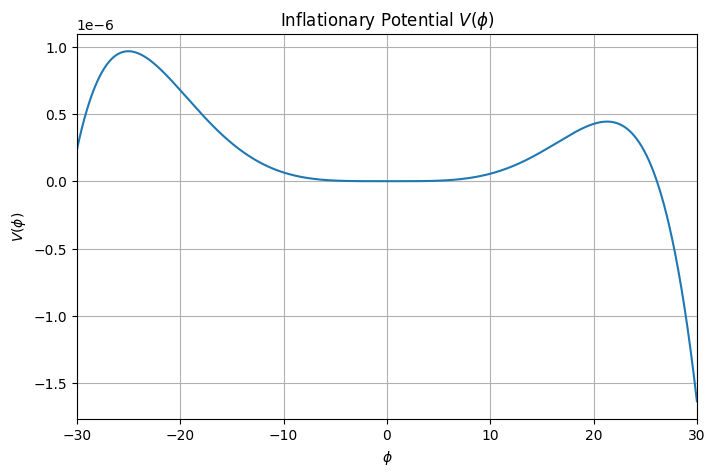

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Generate x-values
phi = np.linspace(-30, 30, 1000)

Vfunc = lambda x: V(x,goodStates[0])
V_vals = [Vfunc(x) for x in phi]
# Plot
plt.figure(figsize=(8,5))
plt.plot(phi, V_vals)
plt.xlim(-30, 30)
plt.xlabel(r'$\phi$')
plt.ylabel(r'$V(\phi)$')
plt.title(r'Inflationary Potential $V(\phi)$')
plt.grid(True)

plt.show()

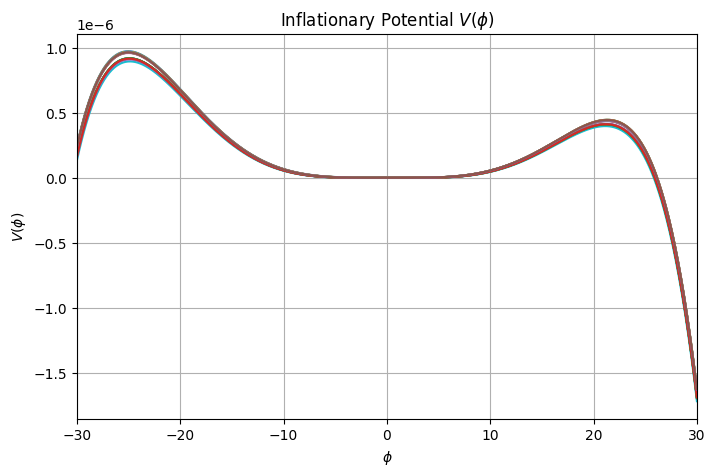

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
# Generate x-values
phi = np.linspace(-30, 30, 1000)

plt.figure(figsize=(8, 5))

for i, state in enumerate(unique):
    V_vals = [V(x, state) for x in phi]
    plt.plot(phi, V_vals, label=f"goodState {i}")

plt.xlim(-30, 30)
plt.xlabel(r'$\phi$')
plt.ylabel(r'$V(\phi)$')
plt.title(r'Inflationary Potential $V(\phi)$')
plt.grid(True)

plt.show()

We can see that the graphs computed in Part A are all relativilty similar.

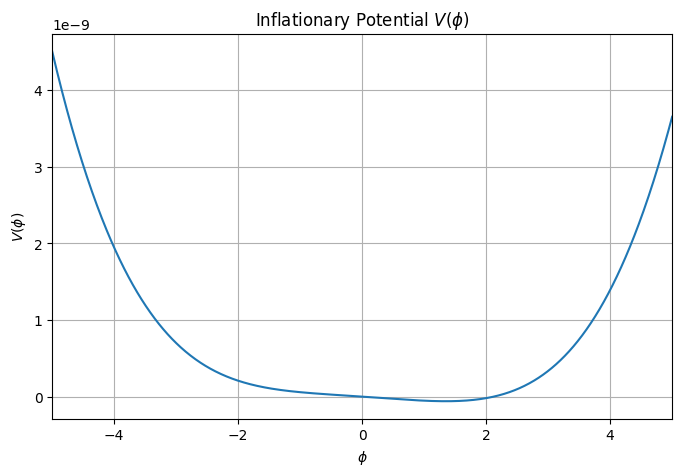

In [ ]:
import matplotlib.pyplot as plt

# Generate x-values
phi = np.linspace(-5, 5, 1000)

Vfunc = lambda x: V(x,goodStates[0])
V_vals = [Vfunc(x) for x in phi]
# Plot
plt.figure(figsize=(8,5))
plt.plot(phi, V_vals)
plt.xlim(-5, 5)
plt.xlabel(r'$\phi$')
plt.ylabel(r'$V(\phi)$')
plt.title(r'Inflationary Potential $V(\phi)$')
plt.grid(True)

plt.show()

**Looking at another example of genetic alogirthm and RL**


I choose my search space to be $x,y,z \in [-100,100]$.

As my phenotype is $xyz$, therefore my genotype length is approximatly 22-23 bits. So my population size should be around 100.

My Geneotype will be in base 10, with the 6 bits being seperated into 2 bits giving me my x, y and z. As will want to swap genes so x, y and z and not something below that

I will use tourmant selection.

Will use one-point cross over.


Mutation add a reasonably sized pertubation, will tweak this as run algorithm. I am at the moment not sure whether a large or small pertubation would be more effective.


In [ ]:
import random as rnd
import heapq as hpq
import numpy as np
# Generate initial population
def intPop(popSize, searchRange):
  # Population List
  pop = []

  for i in range(popSize):
    genome = []
    for j in range(3):
      #Makes sense to start with genome biased towards small numbers
      genome.append(int(rnd.triangular(searchRange[0], searchRange[1])))
    pop.append(genome)
  return pop

# Fitness Function, Stop if exact solution found, output solution, no of generations
def fitFnc(genome,k):

  # Caculate score
  score = -abs(genome[0]**3 + genome[1]**3 + genome[2]**3 - k)

  return score

# Tourmanent Selection Function
def trmSlc(TrmSet,slcNo):
  # Input:
  #   tmrSlc - selected genomes for our tourmanent, each element {genome, its score}
  #   slcNo  - No that will be selected

  # Why right the algorithm when u have a library! This sorts in O(klogM) time
  selectedGenomes = hpq.nlargest(slcNo,TrmSet,key=lambda x:x[1])
  return selectedGenomes


# One point cross over Function
def onePtCrs(parent1,parent2):
  #Choose cross over point
  #Dont start cross over at 0 cos this would give parent1 and parent 2 as result
  crossOverPoint = rnd.randint(1,len(parent1)-1)

  child1 = parent1[:crossOverPoint] + parent2[crossOverPoint:]
  child2 = parent2[:crossOverPoint] + parent1[crossOverPoint:]

  return child1, child2



# Mutation Function
def mutate(genome, mutationProb,searchRange):
  low, high = searchRange
  for i in range(len(genome)):
    if rnd.random() < mutationProb:
      #I initially used a guassian but this works better I found
      genome[i] += rnd.randint(int(low*0.1),int(high*0.1))
      genome[i] = max(low,min(high,genome[i]))

  return genome

  # if rnd.random() < mutationProb:
  #   #Choose gene that will mutate
  #   point = rnd.randint(0,len(genome)-1)
  #   gene = genome[point]
  #   gene += rnd.gauss(0,(max-min)*0.1)
  #   gene = min + (gene-min) % (max-min)
  #   genome[point] = int(gene)
  # return genome


#Main Function
def geneticAlgo(k,popSize,searchRange,maxGen,mutationProb):

  #Create population
  pop = intPop(popSize,searchRange)

  for j in range(maxGen):
    #Selection
    # Create tuplet
    score = []
    for i in pop:
      fit = fitFnc(i,k)
      #Check if get solution
      if fit == 0:
        print(f"Found Solution: {i}, in {j} generations")
        return
      score.append(fit)
    pop = list(zip(pop,score))

    newpop = []
    #5% by Elitism
    for x in trmSlc(pop,round(popSize*0.05)):
      newpop.append(x[0])
    #95% by Tourmanent Selection and 1 point cross over
    while len(newpop) < popSize:
      #Tourmant size of 5
      sample = rnd.sample(pop,5)
      parent1 = trmSlc(sample,1)
      sample = rnd.sample(pop,5)
      parent2 = trmSlc(sample,1)
      [child1,child2] = onePtCrs(parent1[0][0],parent2[0][0])
      newpop.append(mutate(child1,mutationProb,searchRange))
      if len(newpop) < popSize:
        newpop.append(mutate(child2,mutationProb,searchRange))

    best = max(pop, key=lambda x: x[1])
    # print(j, best)

    pop = newpop

  #Stop when max generations reached
  print(f"No solution found, best solution {trmSlc(pop,1)}")
  return

geneticAlgo(70,100,[-100,100],1000,0.1)

Found Solution: [57, -57, 0], in 1 generations


/tmp/ipykernel_1318/1131090482.py:21: RuntimeWarning: divide by zero encountered in log
  score = -abs(genome[0]**3 + genome[1]**3 + genome[2]**3 - k)/np.log(abs(genome[0]**3 + genome[1]**3 + genome[2]**3))


This was intialy done with the cross over being done seperatly between genes, however when reading a paper on the genetic algorithm used in cosmic inflation it mentions that this is generaly a bad method. So I have redone splitting into binary and then doing cross over.

In [ ]:
import random as rnd
import heapq as hpq
# Generate initial population
def intPop(popSize, m):
  # Population List
  pop = []

  for i in range(popSize):
    genome = []
    for j in range(3):
      #Makes sense to start with genome biased towards small numbers
      genome.append(int(rnd.triangular(-2**m, 2**m-1)))
    pop.append(genome)
  return pop

# Fitness Function, Stop if exact solution found, output solution, no of generations
def fitFnc(genome,k):

  # Caculate score
  score = -abs(genome[0]**3 + genome[1]**3 + genome[2]**3 - k)

  return score

# Tourmanent Selection Function
def trmSlc(TrmSet,slcNo):
  # Input:
  #   tmrSlc - selected genomes for our tourmanent, each element {genome, its score}
  #   slcNo  - No that will be selected

  # Why right the algorithm when u have a library! This sorts in O(klogM) time
  selectedGenomes = hpq.nlargest(slcNo,TrmSet,key=lambda x:x[1])
  return selectedGenomes


#Convert State into Binary Vector in two's compliment representation
def numToBin(state,m):
  #Width of our numbers is m+1
  width = m+1
  bitX = [(state[0] >> i) & 1 for i in reversed(range(width))]
  bitY = [(state[1] >> i) & 1 for i in reversed(range(width))]
  bitZ = [(state[2] >> i) & 1 for i in reversed(range(width))]

  return bitX + bitY + bitZ

#Converts bit to Num
def bitToNum(bits):
  n = len(bits)
  state = 0
  for b in bits:
    state = (state << 1) | b
  if bits[0] == 1:
    state -= (1 << n)
  return state

#Converts our bitVec to numVec
def binToNum(bitvec, m):
    width = m + 1

    x_bits = bitvec[0:width]
    y_bits = bitvec[width:2*width]
    z_bits = bitvec[2*width:3*width]

    return (
        bitToNum(x_bits),
        bitToNum(y_bits),
        bitToNum(z_bits)
    )

# One point cross over Function
def onePtCrs(parent1,parent2,m):
  #Convert into binary
  parent1 = numToBin(parent1,m)
  parent2 = numToBin(parent2,m)
  #Choose cross over point
  #Dont start cross over at 0 cos this would give parent1 and parent 2 as result
  crossOverPoint = rnd.randint(1,len(parent1)-1)

  child1 = parent1[:crossOverPoint] + parent2[crossOverPoint:]
  child2 = parent2[:crossOverPoint] + parent1[crossOverPoint:]

  child1 = binToNum(child1,m)
  child2 = binToNum(child2,m)

  #Convert back into numbers

  return child1, child2



# Mutation Function
def mutate(genome, mutationProb,m):
  genome = numToBin(genome,m)
  for i in range(len(genome)):
    if rnd.random() < mutationProb:
      #Flip bit
      genome[i] ^= 1
  genome = binToNum(genome,m)
  return genome

  # if rnd.random() < mutationProb:
  #   #Choose gene that will mutate
  #   point = rnd.randint(0,len(genome)-1)
  #   gene = genome[point]
  #   gene += rnd.gauss(0,(max-min)*0.1)
  #   gene = min + (gene-min) % (max-min)
  #   genome[point] = int(gene)
  # return genome


#Main Function
def geneticAlgo(k,popSize,m,maxGen):
  mutationProb =  1 / (3 * (m + 1))

  #Create population
  pop = intPop(popSize,m)

  for j in range(maxGen):
    #Selection
    # Create tuplet
    score = []
    for i in pop:
      fit = fitFnc(i,k)
      #Check if get solution
      if fit == 0:
        print(f"Found Solution: {i}, in {j} generations")
        return
      score.append(fit)
    pop = list(zip(pop,score))

    newpop = []
    #1% by Elitism
    for x in trmSlc(pop,round(popSize*0.01)):
      newpop.append(x[0])
    #95% by Tourmanent Selection and 1 point cross over
    while len(newpop) < popSize:
      #Tourmant size of 5
      sample = rnd.sample(pop,3)
      parent1 = trmSlc(sample,1)
      sample = rnd.sample(pop,3)
      parent2 = trmSlc(sample,1)
      [child1,child2] = onePtCrs(parent1[0][0],parent2[0][0],m)
      newpop.append(mutate(child1,mutationProb,m))
      if len(newpop) < popSize:
        newpop.append(mutate(child2,mutationProb,m))

    # best = max(pop, key=lambda x: x[1])
    # print(j, best)

    pop = newpop

  # Stop when max generations reached
  scored_pop = [(g, fitFnc(g, k)) for g in pop]
  best = max(scored_pop, key=lambda x: x[1])

  print(f"No solution found, best solution {best[0]}, score {best[1]}")

  #Stop when max generations reached
  # print(f"No solution found, best solution {trmSlc(pop,1)}")
  return

geneticAlgo(70,80,6,10000)
# geneticAlgo(33,1000,55,1000,0.1)

No solution found, best solution (2, 4, -1), score -1


Here we can see how using the binary genome works much better I am running the same parameters for both and yet, only the. binary one seems to find me results. Tried running for k = 33, however it took to long to run.

Tried changing mutation probability, doesn't seem to help though

In [ ]:
import random as rnd
import heapq as hpq
# Generate initial population
def intPop(popSize, m):
  # Population List
  pop = []

  for i in range(popSize):
    genome = []
    for j in range(3):
      #Makes sense to start with genome biased towards small numbers
      genome.append(int(rnd.triangular(-2**m, 2**m-1)))
    pop.append(genome)
  return pop

# Fitness Function, Stop if exact solution found, output solution, no of generations
def fitFnc(genome,k):

  # Caculate score
  score = -abs(genome[0]**3 + genome[1]**3 + genome[2]**3 - k)

  return score

# Tourmanent Selection Function
def trmSlc(TrmSet,slcNo):
  # Input:
  #   tmrSlc - selected genomes for our tourmanent, each element {genome, its score}
  #   slcNo  - No that will be selected

  # Why right the algorithm when u have a library! This sorts in O(klogM) time
  selectedGenomes = hpq.nlargest(slcNo,TrmSet,key=lambda x:x[1])
  return selectedGenomes


#Convert State into Binary Vector in two's compliment representation
def numToBin(state,m):
  #Width of our numbers is m+1
  width = m+1
  bitX = [(state[0] >> i) & 1 for i in reversed(range(width))]
  bitY = [(state[1] >> i) & 1 for i in reversed(range(width))]
  bitZ = [(state[2] >> i) & 1 for i in reversed(range(width))]

  return bitX + bitY + bitZ

#Converts bit to Num
def bitToNum(bits):
  n = len(bits)
  state = 0
  for b in bits:
    state = (state << 1) | b
  if bits[0] == 1:
    state -= (1 << n)
  return state

#Converts our bitVec to numVec
def binToNum(bitvec, m):
    width = m + 1

    x_bits = bitvec[0:width]
    y_bits = bitvec[width:2*width]
    z_bits = bitvec[2*width:3*width]

    return (
        bitToNum(x_bits),
        bitToNum(y_bits),
        bitToNum(z_bits)
    )

# One point cross over Function
def onePtCrs(parent1,parent2,m):
  #Convert into binary
  parent1 = numToBin(parent1,m)
  parent2 = numToBin(parent2,m)
  #Choose cross over point
  #Dont start cross over at 0 cos this would give parent1 and parent 2 as result
  crossOverPoint = rnd.randint(1,len(parent1)-1)

  child1 = parent1[:crossOverPoint] + parent2[crossOverPoint:]
  child2 = parent2[:crossOverPoint] + parent1[crossOverPoint:]

  child1 = binToNum(child1,m)
  child2 = binToNum(child2,m)

  #Convert back into numbers

  return child1, child2



# Mutation Function
def mutate(genome, mutationProb,m):
  genome = numToBin(genome,m)
  for i in range(len(genome)):
    if rnd.random() < mutationProb:
      #Flip bit
      genome[i] ^= 1
  genome = binToNum(genome,m)
  return genome

  # if rnd.random() < mutationProb:
  #   #Choose gene that will mutate
  #   point = rnd.randint(0,len(genome)-1)
  #   gene = genome[point]
  #   gene += rnd.gauss(0,(max-min)*0.1)
  #   gene = min + (gene-min) % (max-min)
  #   genome[point] = int(gene)
  # return genome


#Main Function
def geneticAlgo(k,popSize,m,maxGen):
  mutationProb_intial =  0.4
  mutationProb = mutationProb_intial

  #Create population
  pop = intPop(popSize,m)

  for j in range(maxGen):
    mutationProb *= 0.9999
    #Selection
    # Create tuplet
    score = []
    for i in pop:
      fit = fitFnc(i,k)
      #Check if get solution
      if fit == 0:
        print(f"Found Solution: {i}, in {j} generations")
        return
      score.append(fit)
    pop = list(zip(pop,score))

    newpop = []
    #1% by Elitism
    for x in trmSlc(pop,round(popSize*0.01)):
      newpop.append(x[0])
    #95% by Tourmanent Selection and 1 point cross over
    while len(newpop) < popSize:
      #Tourmant size of 5
      sample = rnd.sample(pop,3)
      parent1 = trmSlc(sample,1)
      sample = rnd.sample(pop,3)
      parent2 = trmSlc(sample,1)
      [child1,child2] = onePtCrs(parent1[0][0],parent2[0][0],m)
      newpop.append(mutate(child1,mutationProb,m))
      if len(newpop) < popSize:
        newpop.append(mutate(child2,mutationProb,m))

    # best = max(pop, key=lambda x: x[1])
    # print(j, best)

    pop = newpop

  # Stop when max generations reached
  scored_pop = [(g, fitFnc(g, k)) for g in pop]
  best = max(scored_pop, key=lambda x: x[1])

  print(f"No solution found, best solution {best[0]}, score {best[1]}")

  #Stop when max generations reached
  # print(f"No solution found, best solution {trmSlc(pop,1)}")
  return

geneticAlgo(70,150,10,2000)
# geneticAlgo(33,1000,55,1000,0.1)

No solution found, best solution (586, -586, 5), score -55


This function which just randomly guesses a solution, does seem to out perform both my genetic algorithms. Either one which swaps just the genes and one which makes up within the genes themselves. I am not sure what mistake I making with my genetic algorithm, or if it simply not suited for this task

In [ ]:

best_val = 1000000
k = 70
while best_val > 0:
  x = rnd.randint(-100,100)
  y = rnd.randint(-100,100)
  z = rnd.randint(-100,100)
  val = abs(-k + x**3 + y**3 + z**3)
  if val < best_val:
    best_val = val
    best_x = x
    best_y = y
    best_z = z

print(best_val,best_x,best_y,best_z)

0 63 23 -64


For any k whose solution is greater than O(10), any mutation (if ur genome is base 10) causes O(100) or more change in ur fitness. If in base 10 then ur are just exploring a small state space ineffeciently as the same numbers just get passsed around when choosing new kids. Mutation causes random jumps.


My point is having a low fitness doesn't seem to greatly predict how close you are to the solution. My last piece of code which randomly searches the state space, seems to outperform all my genetic algorithm algorithms, as it can run much faster and therefore visit more states.

**Q3 Part II**
We will know re-approach the problem from the perspective of reinforcement learning.

Again we must provide a finite state space (*It seems from the lectures although its not 100% clear that its called state space when its RL and search space when its genetic algorithm*

We define $x,y,z \in [-N,N]$ same as for genetic algorithm

We must now define a set of actions our action space, $A$:

*I thought it seemed reasonable for my action space to be minimum number of actions to explore the whole space*

1.   x -> x + 1
2.   x -> x - 1
3.   y -> y + 1
4.   y -> y - 1
5.   z -> z + 1
6.   z -> z - 1

*I thought I could include a stay still but this is pointless at it will not help us reach the target*

7.   Random Jump [x,y,z] -> [x',y',z']


Note: From this set-up we must have on the boundary the rule that we cannot pass over it

Let $S_{bounardy} \subset S$, be the state space where one or more of x, y or z are $\pm$N, the boundary. For which ever case we are in one or more of the previous actions is not allowed such that it stops us leaving the boundary.

Compared to our previous genetic algorithm which is more of a mad unpredictable splash at the answer which in this setup is expected to work better as we don't understand the fundmental, its very complicated and doesn't follow a simple pattern.

Sum_of_3_cubes.svg


As can be seen from the above image, to try and make some sense of the pattern I plotted a heat map of x,y and z
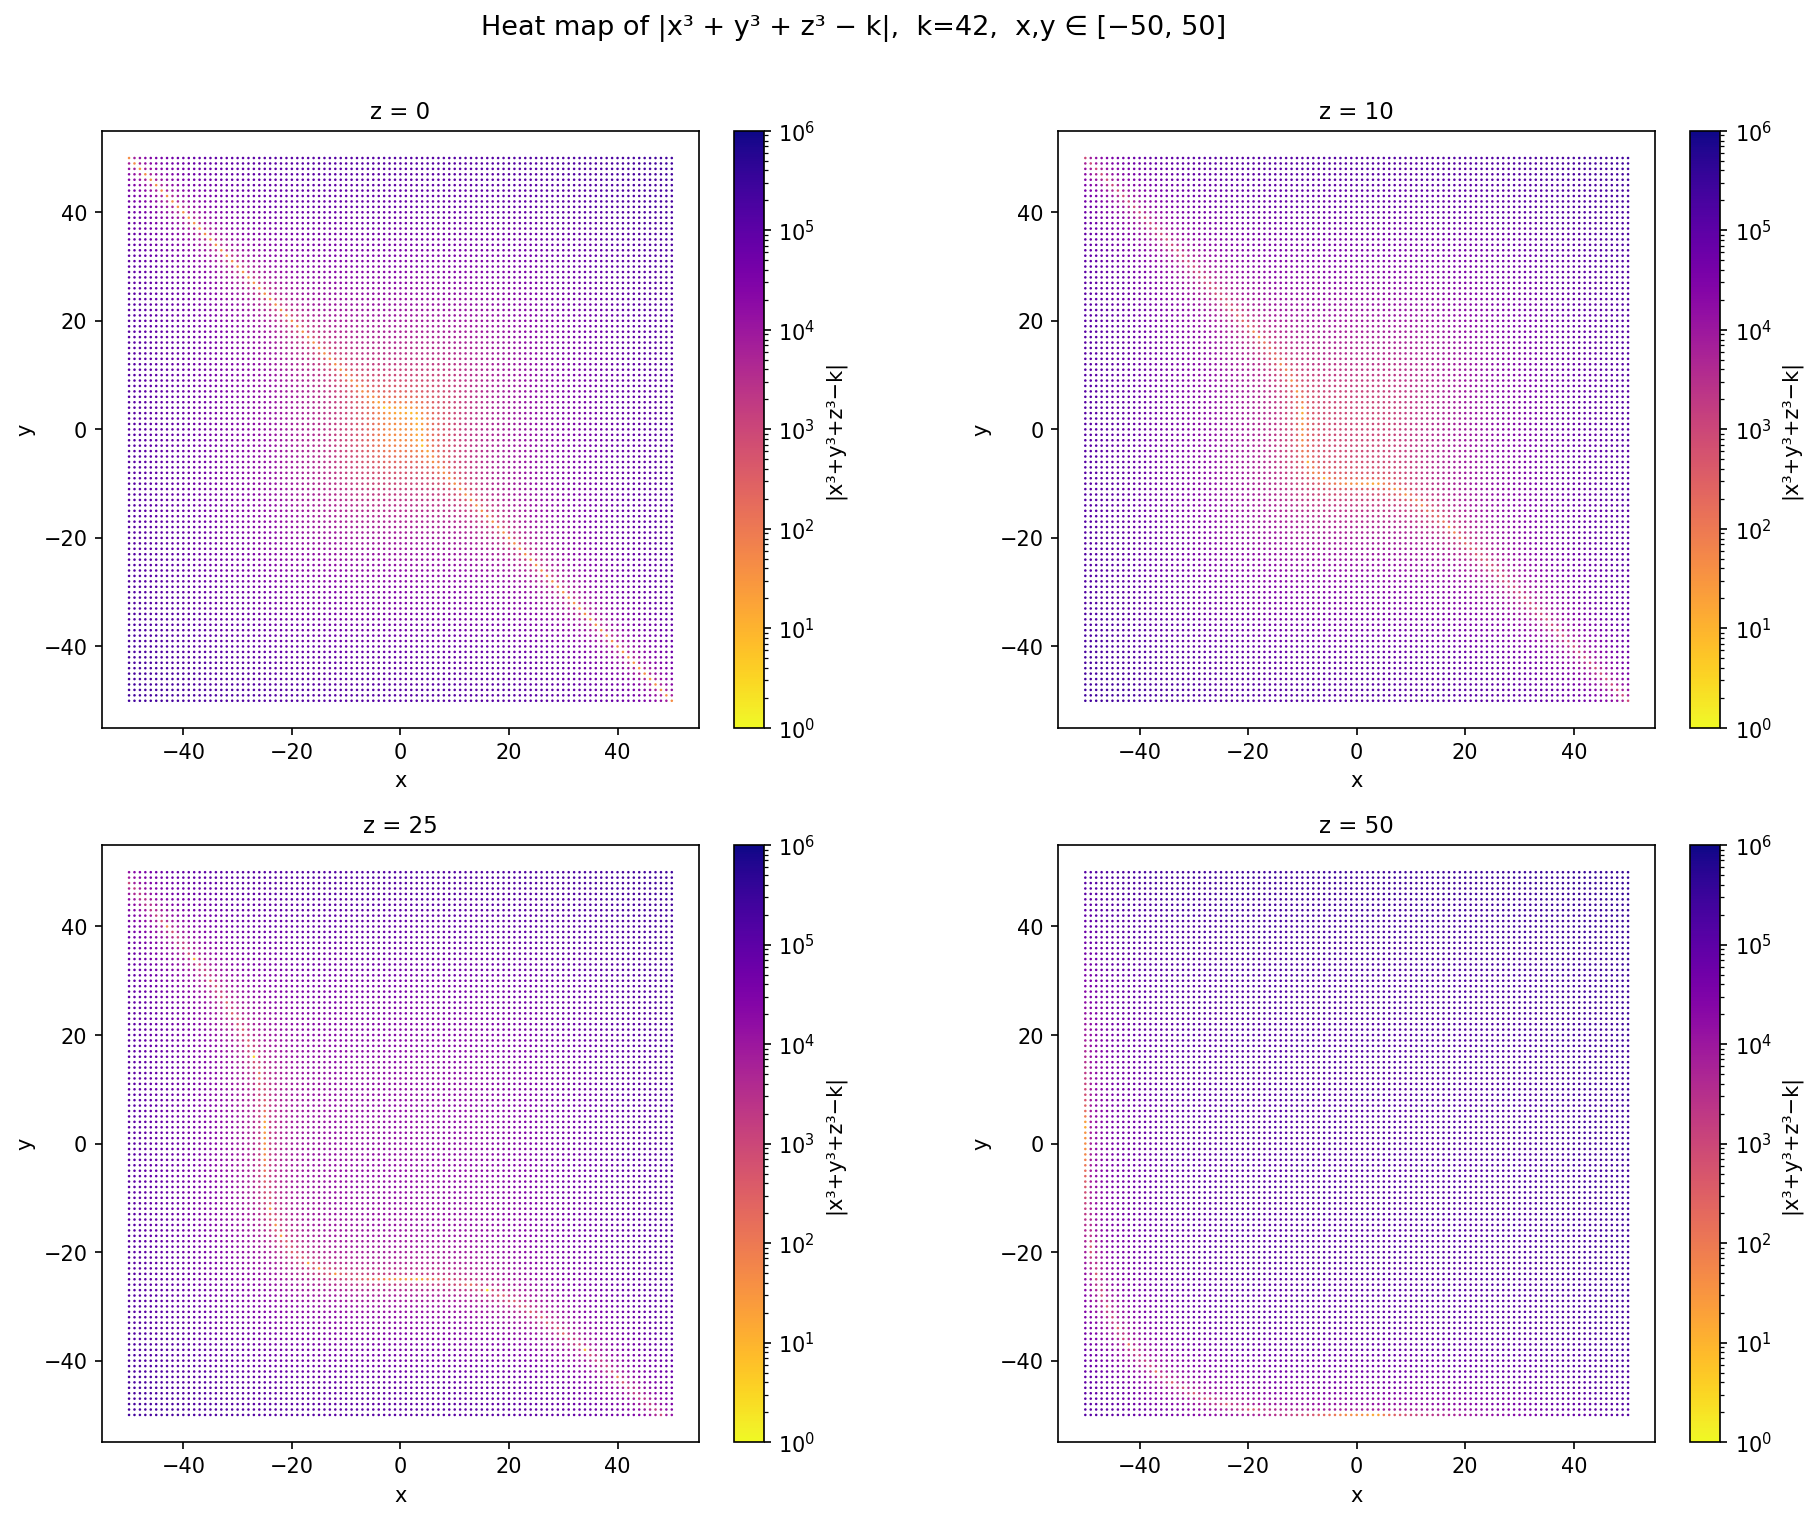


From this it suggests the most logical reward is one which penalises for going to larger $|x^3 + y^3 + z^3 -k|$ values heavily but which generaly allowed system to explore this space.

That being said I suspect this pattern is just there as it corresponds to areas in our state space where x, y and z closley cancel each other out, and so could argue wont be any more productive than just randomly explore the state space. As there is no clear pattern elsewhere this is the approach we shall follow.

Reward:

let $e_t = |x_t^3 + y_t^3 + z_t^3 -k|
$

If: $e_t$ = 0, give extra large reward, + 1000

Else: $e_{t+1} - e_{t}$ reward



Algorithm:
Greedy Policy


For each period:
  1. Start in state $S_0$
  2. Pick $a* = arg max_a Q(s,a)$ (if more than one $a*$ then choice randomly between them)
  3. Moves to state $S_1$
  Go back to Step 1, repeat unitl perform $T$ times

  Then choice new $S_0$ start of new period

  How do find $Q(s,a)$?


  Taking the assumption that all the spaces we have yet to explore are give on average a 0 reward. We can then caculate our after Q each period.

  Initially we knowing nothing, we can only discover Q from exploring our state space. We re-caculate our Qs after each period, however there is a another method.

 **Bellman Equations**


Using the fact that
$G_t = r_{t+1} + γ G_{t+1}$

We substitute into our V and Q, with a bit of rearranging we get:

$Q(s,a)_{expect} = r_{reward} + 𝞬 \arg \mathrm{max}_a Q(s')$,

We could do some fiddling around with this introduce an $α$ and caculate this using a table in which we update our Q as we progress. However in the setup we doing our state space is too large to do this and have a reasonable effect. Instead we shall use a neural network.

Our NN Q we shall denote as $Q_{\theta}$, we can train our network by using $Q_{\theta}$ + greedy policiy to pick our action moving to state $s'$, then use $Q_{\theta}$ again for state $s'$ to compute:

$Q(s,a)_{expect} = r_{reward} + 𝞬 \arg \mathrm{max}_a Q(s')_{\theta}$


Then backprop neural network using MSE from $Q_{\theta}(s,a)$ - $Q(s,a)_{expect}$

This is Q-learning (value-based). In lectures a REINFORCE (policy-based) was also discussed, and actor-critic (a combination of the two). The action space we have outlined is rather small, the only way to expand our action space would be to have more non-random jumps. It is likely that a actor-critic setup would be better, but as discussed later an RL is a bad approach to use for this question given the size of the state space. So we will just stick with Q-learning, using a greedy policy.

I did it this way as in the previous question I did REINFORCE as the question asked for that.


In [ ]:
from os import stat
#Import PyTorch
import torch
import torch.nn as nn
import random

# We define a class for our neural network
class NN(nn.Module):
  def __init__(self, input_size, hidden_size, output_size):
    super(NN, self).__init__()

    self.net = nn.Sequential(
        nn.Linear(input_size, hidden_size),
        nn.ReLU(),
        nn.Linear(hidden_size, output_size)
    )

  def forward(self,x):
      return self.net(x)

#Define our functions

#Greedy Policy
def grdPol(Q, epsilon):
  #Torch outputs its own tensors and so we have to use its own functions
  #to deal with this
  #Output the action we are gonna take

  grdAction = torch.argmax(Q).item()

  if random.random() < epsilon:
    #Apply random action not max
    action = list(range(len(Q)))
    action.remove(grdAction)
    return random.choice(action)
  else:
    #Apply max action
    return grdAction


#New Position
def newPos(m):
    return [
        random.randint(-2**m, 2**m - 1),
        random.randint(-2**m, 2**m - 1),
        random.randint(-2**m, 2**m - 1),
    ]


#Calculate newState
def newState(state, action,m):
  #Store my 1-6 actions as vectors
  localAction = {
      0: (1,0,0),
      1: (-1,0,0),
      2: (0,1,0),
      3: (0,-1,0),
      4: (0,0,1),
      5: (0,0,-1)
  }

  if action == 6:
    #Random Jump
    min = -2**m
    max = 2**m-1
    x = random.randint(min,max)
    y = random.randint(min,max)
    z = random.randint(min,max)
  else:
    x,y,z = localAction[action]

  state = [state[0]+x,state[1]+y,state[2]+z]

  return state

#Convert State into Binary PyTorch Vector in two's compliment representation
def numToBin(state,m):
  #Width of our numbers is k+1
  width = m+1
  bitX = [(state[0] >> i) & 1 for i in reversed(range(width))]
  bitY = [(state[1] >> i) & 1 for i in reversed(range(width))]
  bitZ = [(state[2] >> i) & 1 for i in reversed(range(width))]

  #Combine
  state = bitX + bitY + bitZ
  return torch.tensor(state,dtype = torch.float32)

#Caculate Reward
def cltReward(state,next_state,k):
  E = abs(-k+state[0]**3+state[1]**3+state[2]**3)
  E_next = abs(-k+next_state[0]**3+next_state[1]**3+next_state[2]**3)
  if E_next == 0:
    done = True
    reward = 1000
  else:
    done = False
    reward = E_next-E
  return reward, done


#Computes the backprop from one step of our RL
def step(net, start_state,epsilon,lossFnc,optimizer,gamma,m,k):
  #Find the action
  Q_theta = net(numToBin(start_state,m))
  action = grdPol(Q_theta,epsilon)

  #Caculate new state we move too
  next_state = newState(start_state,action,m)

  #Caculate the reward
  reward, done = cltReward(start_state,next_state,k)

  #Caculate MaxQ(s',a*)
  #Don't need PyTorch to save our values needed for BackProp, as not doing MSE
  #On s'
  with torch.no_grad():
    #Our Greedy Policy has a small hitch, if we arrive at our result, so
    #a set of x,y and z so that x^3 + y^3 + z^3 = k, then we are done
    #So we just add reward
    Q_expect = reward
    #If we are not done also add Q(s')max
    if not done:
      Q_next = net(numToBin(next_state,m))
      #We keep torchmax(Q_next) in tensor format which nealty makes
      #Q_expect in tensor format as well so we can just apply MSE
      Q_expect += gamma*torch.max(Q_next)

  loss = lossFnc(Q_theta[action],Q_expect)

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  return next_state, done



def RL(k,m,epsilon,pNo,T,gamma):

  #Calc input size
  #Our state space is defined by[-N,N] as discussed earlier which defines the size of
  #x, y and z as binary numbers which in turn gives us our input_size
  #One bit is used to give the sign of our x,y and z binary
  #Give our N as 2^m so that we are using all the state space we can
  #Our state space is [-2^m,2^m-1], the -1 is due to 0
  #So each x, y and z is k+1 size
  #So input_size is 3(k+1)
  input_size = 3*(m+1)


  #Calc output size
  #Our output size is 7, which includes our random jump
  output_size = 7

  #Hidden Size, we decide this arbtiarly. I think its better when the hidden layer is a multiple of two
  #cos binary
  hidden_size = 128

  #Create object of this class
  net = NN(input_size, hidden_size, output_size);

  lossFnc = nn.MSELoss()
  optimizer = torch.optim.Adam(net.parameters(), lr=0.001)

  #Number of Periods
  pNo
  #Number of steps Per Period
  T
  #Take a step
  for i in range(pNo):
    current_state = newPos(m)
    for j in range(T):
      current_state, done = step(net, current_state,epsilon,lossFnc,optimizer,gamma,m,k)
      if done:
        return print(f"Found it {current_state}")

  return print(f"Close as we got {current_state}")

#Run state
RL(12,3,0.1,20,100,0.8)

Close as we got [1, 91, -17]
